In [1]:
from mplsoccer import Pitch, FontManager, Sbopen
from matplotlib import rcParams
import matplotlib.pyplot as plt

rcParams['text.color'] = '#c7d5cc'  # set the default text color

parser = Sbopen()
df, related, freeze, tactics = parser.event(3857283)

In [2]:
morocco, belguim = df.team_name.unique()
mask_morocco = (df.type_name == 'Pass') & (df.team_name == morocco)

In [14]:
df_pass = df.loc[mask_morocco, ['x', 'y', 'end_x', 'end_y', 'outcome_name','minute']]
mask_complete = df_pass.outcome_name.isnull()


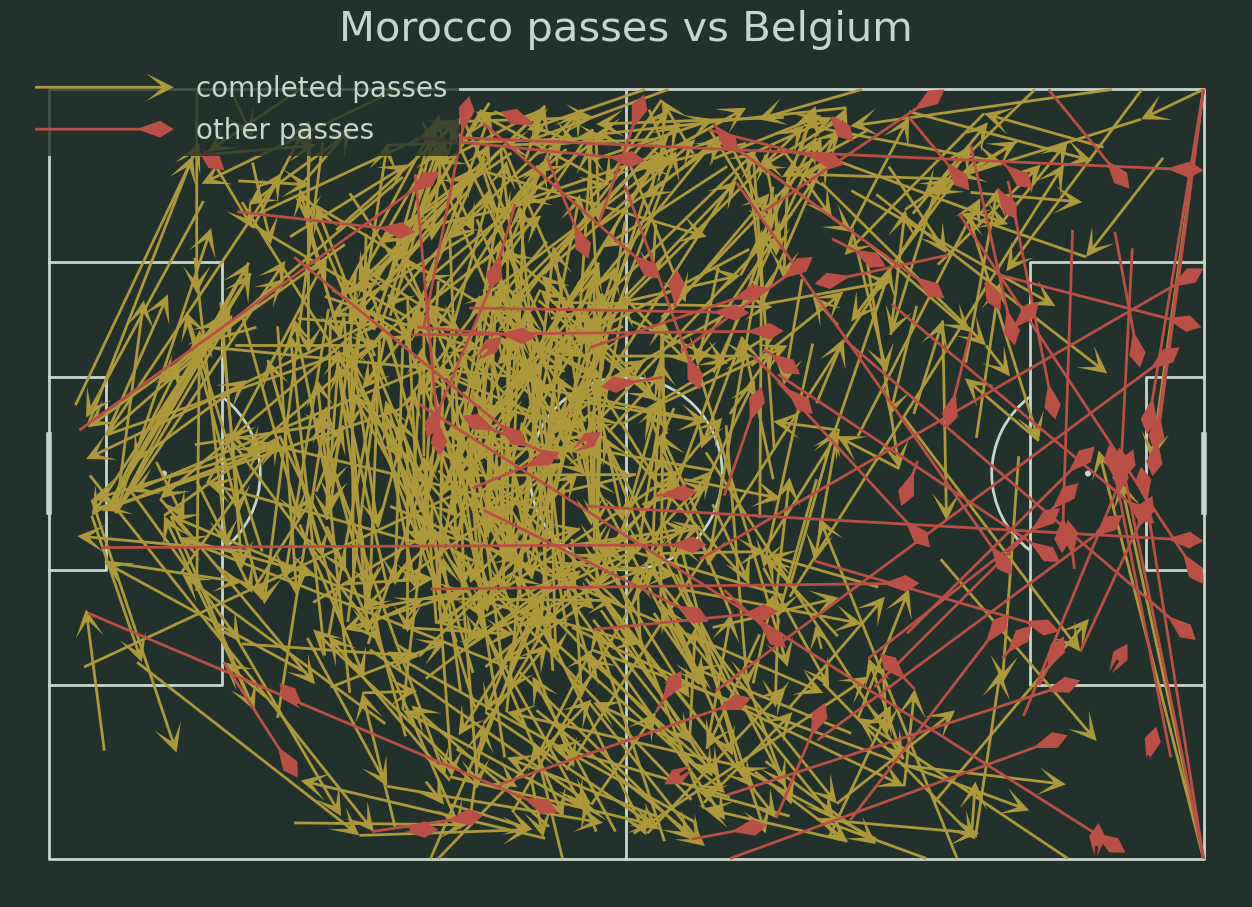

In [15]:
# Set up the pitch
pitch = Pitch(pitch_type='statsbomb', pitch_color='#22312b', line_color='#c7d5cc')
fig, ax = pitch.draw(figsize=(16, 11), constrained_layout=True, tight_layout=False)
fig.set_facecolor('#22312b')

# Plot the completed passes
pitch.arrows(df_pass[mask_complete].x, df_pass[mask_complete].y,
             df_pass[mask_complete].end_x, df_pass[mask_complete].end_y, width=2,
             headwidth=10, headlength=10, color='#ad993c', ax=ax, label='completed passes')

# Plot the other passes
pitch.arrows(df_pass[~mask_complete].x, df_pass[~mask_complete].y,
             df_pass[~mask_complete].end_x, df_pass[~mask_complete].end_y, width=2,
             headwidth=6, headlength=5, headaxislength=12,
             color='#ba4f45', ax=ax, label='other passes')

# Set up the legend
ax.legend(facecolor='#22312b', handlelength=5, edgecolor='None', fontsize=20, loc='upper left')

# Set the title
ax_title = ax.set_title(f'{belguim} passes vs {morocco}', fontsize=30)